# Assignment: Test MNIST model with your own handwritten digits
### Group Submission: Bryon, Sam, Thomas
In this assignment, our focus was to explore and compare various architectures and techniques in Neural Networks to perform handwritten digit recognition using the MNIST dataset. Each task focuses on differnet aspects of the overall goal of this assigment.
### Task 1: Comparing Networks
This submission has built and trained five models for 10 epochs. Produced a single plot comparing the Test Accuracy vs. Epochs for all models, highlighting the superior performance of the CNN due to its preservation of spatial features.
### Task 2: Comparing Activation Functions
The submission built and trained two identical CNNs, ReLU vs. Sigmoid, for 10 epochs. Then a plot was produced comparing their Test Accuracy vs. Epochs. The results demonstrated ReLU's faster convergence and higher accuracy, consistent with its ability to mitigate the vanishing gradient problem.
### Task 3: The Value of Dropout
Then, this submission built and trained two CNNs (one with dropout and one without) for 100 epochs. Produced two plots comparing Training Accuracy and Test Accuracy. The analysis confirmed that Dropout effectively reduces the gap between training and testing performance, which is a key indicator of preventing overfitting.
### Task 4: Personal Handwriting Evaluation
Finally, this submission developed a robust image pre-processing pipeline to resize, invert, and normalize custom images (e.g. 0.jpg, 1.jpg, and so on) to match the MNIST format. Used the trained model to predict the custom digits and analyzed cases where the model made incorrect predictions, attributing errors to variations in stroke width, image centering, or differences in personal handwriting style compared to the MNIST training data.

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize Pixel Values (0-255 -> 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Prepare Data for CNN (Reshape to add channel dimension: 28x28x1)
# The '1' stands for grayscale.
x_train_cnn = x_train.reshape((-1, 28, 28, 1))
x_test_cnn = x_test.reshape((-1, 28, 28, 1))

# 4. Prepare Data for Dense Networks (Flatten: 784)
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print(f"CNN Train Shape: {x_train_cnn.shape}")
print(f"Dense Train Shape: {x_train_flat.shape}")

CNN Train Shape: (60000, 28, 28, 1)
Dense Train Shape: (60000, 784)


In [16]:
def create_cnn_model():
    model = models.Sequential([
        # Convolutional Base
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),

        # Dense Top
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax') # Output layer (0-9)
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Training CNN Model...")
cnn_model = create_cnn_model()
# We store the training history to plot it later
cnn_history = cnn_model.fit(x_train_cnn, y_train, epochs=10,
                            validation_data=(x_test_cnn, y_test), verbose=1)

Training CNN Model...


/Users/thomasallen/PycharmProjects/uwgb-comp-sci-464-group-project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9531 - loss: 0.1478 - val_accuracy: 0.9775 - val_loss: 0.0678
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9897 - val_loss: 0.0344
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9899 - loss: 0.0333 - val_accuracy: 0.9892 - val_loss: 0.0355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9913 - val_loss: 0.0254
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9937 - loss: 0.0200 - val_accuracy: 0.9897 - val_loss: 0.0354
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9909 - val_loss: 0.0316
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9905 - val_loss: 0.0359
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9962 - loss: 

In [11]:
dense_histories = []
layer_counts = [1, 2, 3, 4]

for count in layer_counts:
    print(f"Training Dense Network with {count} Hidden Layers...")

    model = models.Sequential()
    model.add(layers.Input(shape=(784,))) # input layer

    # add the hidden layers based on loop count
    for _ in range(count):
        model.add(layers.Dense(512, activation='relu'))

    # output layer
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train using the flattened data
    history = model.fit(x_train_flat, y_train, epochs=10,
                        validation_data=(x_test_flat, y_test), verbose=1)
    dense_histories.append(history)

Training Dense Network with 1 Hidden Layers...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9399 - loss: 0.2027 - val_accuracy: 0.9702 - val_loss: 0.1005
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9755 - loss: 0.0804 - val_accuracy: 0.9746 - val_loss: 0.0776
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9839 - loss: 0.0515 - val_accuracy: 0.9716 - val_loss: 0.0872
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9882 - loss: 0.0371 - val_accuracy: 0.9793 - val_loss: 0.0659
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9807 - val_loss: 0.0651
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9932 - loss: 0.0209 - val_accuracy: 0.9802 - val_loss: 0.0734
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9933 - loss: 0.0185 - val_accuracy: 0.9822 - val_loss: 0.0695
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3

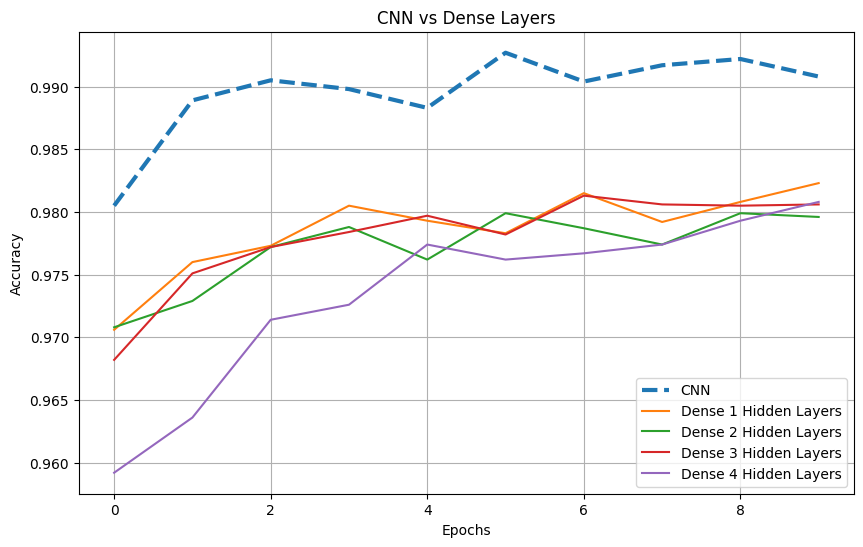

In [13]:
plt.figure(figsize=(10, 6))

# 1. plot CNN history
plt.plot(cnn_history.history['val_accuracy'], label='CNN', linewidth=3, linestyle='--')

# 2. plot Dense histories
for i, history in enumerate(dense_histories):
    num_layers = layer_counts[i]
    plt.plot(history.history['val_accuracy'], label=f'Dense {num_layers} Hidden Layers')

plt.title('CNN vs Dense Layers')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Analysis of CNN vs Dense Layers
The Convolutional Neural Network typically outperforms standard Dense Networks on image data because it preserves spatial hierarchy. A Dense network flattens the image into a line of pixels, destroying the relationship between a pixel and its neighbors (i.e. above, below, left, right). the CNN scans the image using filters, recognizing patterns like edges and curves regardless of where they appear in the image. The Dense networks with 512 nodes have a massive number of connections to learn, which can lead to overfitting or slower convergence. The CNN shares weights across the image, and this makes it more efficient at generalizing the features.
#### Diminishing Returns of Dense Nets
The vanishing gradient problem is apparent when looking at the different Dense hidden layer counts. It is harder to train deep networks without special techniques. Simply put, this is overfitting, where the model memorizes the training data but fails to generalize to the test set.

In [29]:
from tensorflow.keras import utils
import numpy as np

def create_activation_model(activation_name):
    np.random.seed(42)
    utils.set_random_seed(42)

    model = models.Sequential([
        # Convolutional layers
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation=activation_name),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation=activation_name),

        # Dense layers
        layers.Flatten(),
        layers.Dense(64, activation=activation_name),
        layers.Dense(10, activation='linear') # the output is always softmax for multi class classification
    ])

    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

In [30]:
# 1. train the ReLU model
print("ReLU Model training...")
relu_model = create_activation_model('relu')
relu_history = relu_model.fit(x_train_cnn, y_train, epochs=10,
                              validation_data=(x_test_cnn, y_test), verbose=1)

# 2. train sigmoid model
print("\n Sigmoid Model training...")
sigmoid_model = create_activation_model('sigmoid')
sigmoid_history = sigmoid_model.fit(x_train_cnn, y_train, epochs=10,
                                    validation_data=(x_test_cnn, y_test), verbose=1)

ReLU Model training...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9541 - loss: 0.1466 - val_accuracy: 0.9858 - val_loss: 0.0430
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9886 - val_loss: 0.0371
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9902 - loss: 0.0318 - val_accuracy: 0.9890 - val_loss: 0.0382
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9929 - loss: 0.0244 - val_accuracy: 0.9880 - val_loss: 0.0433
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9942 - loss: 0.0196 - val_accuracy: 0.9882 - val_loss: 0.0473
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9853 - val_loss: 0.0576
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accuracy: 0.9907 - val_loss: 0.0355
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc

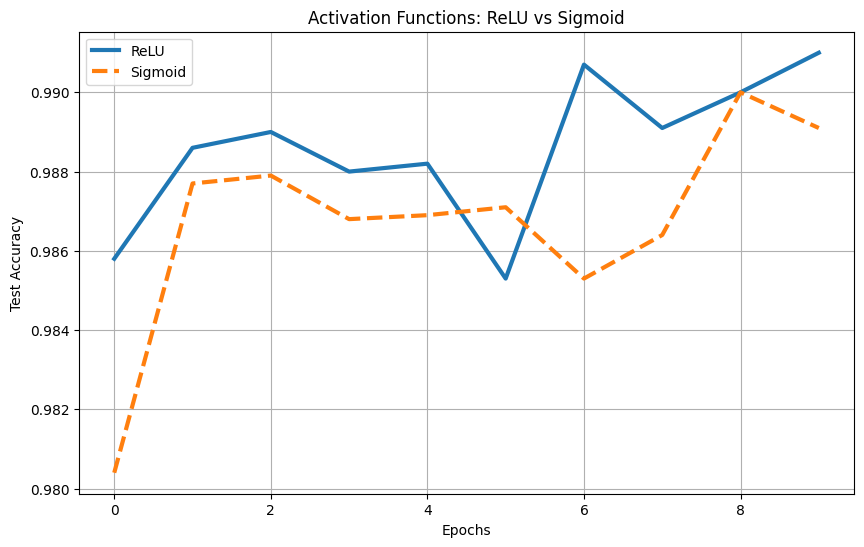

In [31]:
plt.figure(figsize=(10, 6))

# plotting ReLU Accuracy
plt.plot(relu_history.history['val_accuracy'], label='ReLU', linewidth=3)

# plotting sigmoid accuracy
plt.plot(sigmoid_history.history['val_accuracy'], label='Sigmoid', linewidth=3, linestyle='--')

plt.title('Activation Functions: ReLU vs Sigmoid')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Analysis of ReLU vs Sigmoid Activation Functions
The results from above indicate that ReLU generally outperforms Sigmoid in achieving higher accuracy. Sigmoid appears to have lower accuracy at the starting epochs when compared to ReLU, but reaches almost the same, although still lower, accuracy than ReLU. Here are a few (possible) reasons why this is the case.
### Vanishing Gradient Problem
Sigmoid puts all input numbers into a range between 0 and 1. For very high or very low numbers, the curve will become flat. When the curve is flat, the gradient is close to zero (i.e. the slope is close to 0). During backpropagation, the network multiplies these small gradients together. If they are close to 0, the sigal will vanish, and the weights deep in the network will stop updating. Thus, the network will not learn anymore. ReLU does not encounter this issue, because ReLU is linear for all positive values. Its derivative is exactly 1 for all positive inputs. The gradients will not vanish as it passes back through the layers, thus allowing deep networks to quickly and effectively learn.
### Computational Efficiency
Calculating sigmoid requires an exponent e^-x. This is computationally more expensive than ReLU, which is much simpler. ReLU uses max(0, x), and this will make the training faster per epoch.
### Sparsity
ReLU outputs actual zeros for negative inputs. Some neurons are completely inactive at any given time. This "sparsity" can actually help the model generalize better and make the representation more efficient. Sigmoid neurons are almost always outputting some non-zero value, however.

In [20]:
def create_dropout_model(use_dropout=False):
    model = models.Sequential()

    # block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25)) # drop 25% of neurons

    # block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    # block 3
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    # dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.50)) # should be higher in dense layers

    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [21]:
EPOCHS = 100

# 1. train standard model - no dropout
print(f"training standard model for {EPOCHS} epochs...")
std_model = create_dropout_model(use_dropout=False)
std_history = std_model.fit(x_train_cnn, y_train, epochs=EPOCHS,
                            validation_data=(x_test_cnn, y_test), verbose=1)

# 2. train WITH dropout model
print(f"\ntraining dropour model for {EPOCHS} epochs...")
dropout_model = create_dropout_model(use_dropout=True)
dropout_history = dropout_model.fit(x_train_cnn, y_train, epochs=EPOCHS,
                                    validation_data=(x_test_cnn, y_test), verbose=1)

training standard model for 100 epochs...
Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9520 - loss: 0.1533 - val_accuracy: 0.9853 - val_loss: 0.0419
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9860 - loss: 0.0462 - val_accuracy: 0.9897 - val_loss: 0.0324
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9898 - loss: 0.0323 - val_accuracy: 0.9906 - val_loss: 0.0277
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9900 - val_loss: 0.0307
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9941 - loss: 0.0195 - val_accuracy: 0.9935 - val_loss: 0.0244
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9954 - loss: 0.0148 - val_accuracy: 0.9911 - val_loss: 0.0290
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9899 - val_loss: 0.0399
Epoch 8/100
1875/1875 ━━━━━━━━━━━━

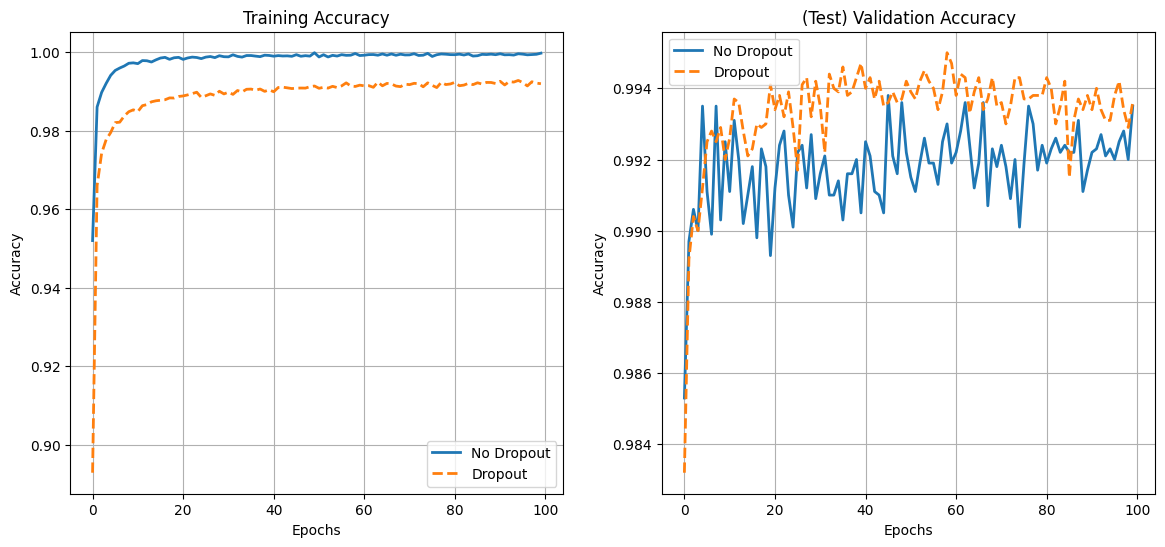

In [23]:
plt.figure(figsize=(14, 6))

# Graph 1: training accuracy
plt.subplot(1, 2, 1)
plt.plot(std_history.history['accuracy'], label='No Dropout', linewidth=2)
plt.plot(dropout_history.history['accuracy'], label='Dropout', linewidth=2, linestyle='--')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Graph 2: test accuracy
plt.subplot(1, 2, 2)
plt.plot(std_history.history['val_accuracy'], label='No Dropout', linewidth=2)
plt.plot(dropout_history.history['val_accuracy'], label='Dropout', linewidth=2, linestyle='--')
plt.title('(Test) Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## Analysis: Training Accuracy & Validation Accuracy Between No Dropout vs. Dropout
### Without Dropout
The training accuracy for no dropout reaches close to 1.0 (100%) accuracy in a shot amount of epochs. However, the test accuracy hits a soft ceiling before 0.994 and no longer improves, and trends downward towards the final epochs (after 60 or so). The gap between training and test accuracy is the case of overfitting. The model has memorized the training images but cannot generalize to the new ones.
### With Dropout
The training accuracy is lower because it's generally harder to learn when neurons keep disappearing. Imagine trying to learn a new subject but are suddenly forgetful at some time. However, the test accuracy is generally higher than the standard model in the later epochs.


NameError: name 'std_history' is not defined

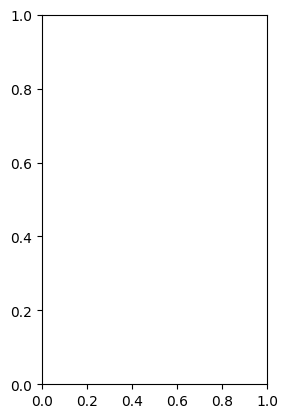

In [32]:
plt.subplot(1, 2, 1)
plt.plot(std_history.history['accuracy'], label='No Dropout', linewidth=2)
plt.plot(drop_history.history['accuracy'], label='With Dropout', linewidth=2, linestyle='--')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Graph 2: Test Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(std_history.history['val_accuracy'], label='No Dropout', linewidth=2)
plt.plot(drop_history.history['val_accuracy'], label='With Dropout', linewidth=2, linestyle='--')
plt.title('Test (Validation) Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

The label of the image at index 42604 is: 5



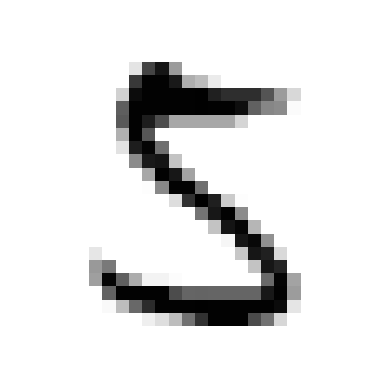

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # Required if you haven't loaded the data yet


# We'll use the training set for this example: X is x_train, y is y_train
X = x_train
y = y_train
# ---------------------------------------------

# Display the image from a random index
# 1. Get a random index. NumPy array length is len(X).
random_index = np.random.randint(0, len(X))

# 2. Extract the image and label directly using NumPy indexing.
# No .iloc or .values needed, as X and y are already NumPy arrays.
some_digit = X[random_index]
some_label = y[random_index]

# Display the image and the label
print(f"The label of the image at index {random_index} is: {some_label}\n")

# 3. Reshape the image (The Keras-loaded X is already (N, 28, 28), so no reshape is strictly necessary
# if you just plot X[random_index], but we keep the variable name for consistency)
some_digit_image = some_digit # X[random_index] is already (28, 28)

# 4. Use "binary" or "gray" colormap.
# Note: Keras default data is typically 0-255, so 'gray' or 'binary' is best.
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [7]:
import numpy as np
import tensorflow as tf
# Assuming you have loaded the data as standard Keras/NumPy arrays:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 1. Convert to float data type
# Standard Scaler works best on float data
X_train = x_train.astype(np.float32)
X_test = x_test.astype(np.float32)

# 2. Calculate the mean and standard deviation from the TRAINING DATA
# This is equivalent to scaler.fit(X_train)
mean_train = X_train.mean()
std_train = X_train.std()

# We must ensure we don't divide by zero if the data is constant
if std_train == 0:
    std_train = 1.0

# 3. Apply standardization to both training and test data
# This is equivalent to scaler.transform(X)
X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

print("--- Standardization Complete ---")
print(f"Mean of X_train after scaling: {X_train.mean():.4f}") # Should be close to 0
print(f"Std Dev of X_train after scaling: {X_train.std():.4f}") # Should be close to 1
print(f"Mean of X_test after scaling (using training mean): {X_test.mean():.4f}")

--- Standardization Complete ---
Mean of X_train after scaling: 0.0000
Std Dev of X_train after scaling: 1.0000
Mean of X_test after scaling (using training mean): 0.0060


In [8]:

from sklearn.neural_network import MLPClassifier

# Initialize the neural network
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation = 'relu',
                    solver='adam', max_iter=100, random_state=42)

In [9]:
import numpy as np
from sklearn.neural_network import MLPClassifier # Assuming this is your classifier

# --- Existing Data Shapes (Before Fix) ---
# X_train.shape is (60000, 28, 28)
# X_test.shape is (10000, 28, 28)

# 1. Store the number of samples (60000)
n_samples_train = X_train.shape[0]
n_samples_test = X_test.shape[0]
n_features = 28 * 28 # 784 pixels per image

# 2. Reshape (Flatten) the training and testing data

# Option A: Use .reshape()
X_train_flat = X_train.reshape(n_samples_train, n_features)
X_test_flat = X_test.reshape(n_samples_test, n_features)

# OR Option B (More common and concise): Use -1 to infer the sample count
# This is preferred as it is robust to different batch sizes
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print(f"Original X_train shape: {X_train.shape}")
print(f"Flattened X_train shape: {X_train_flat.shape}")

# 3. Fit the model using the flattened data
# Assuming 'mlp' is your initialized MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=50, random_state=42)
mlp.fit(X_train_flat, y_train)

print("\nModel trained successfully with flattened data!")

Original X_train shape: (60000, 28, 28)
Flattened X_train shape: (60000, 784)

Model trained successfully with flattened data!


Processing 10 potential files found at ./handwritten_digits_thomas/*.jpg


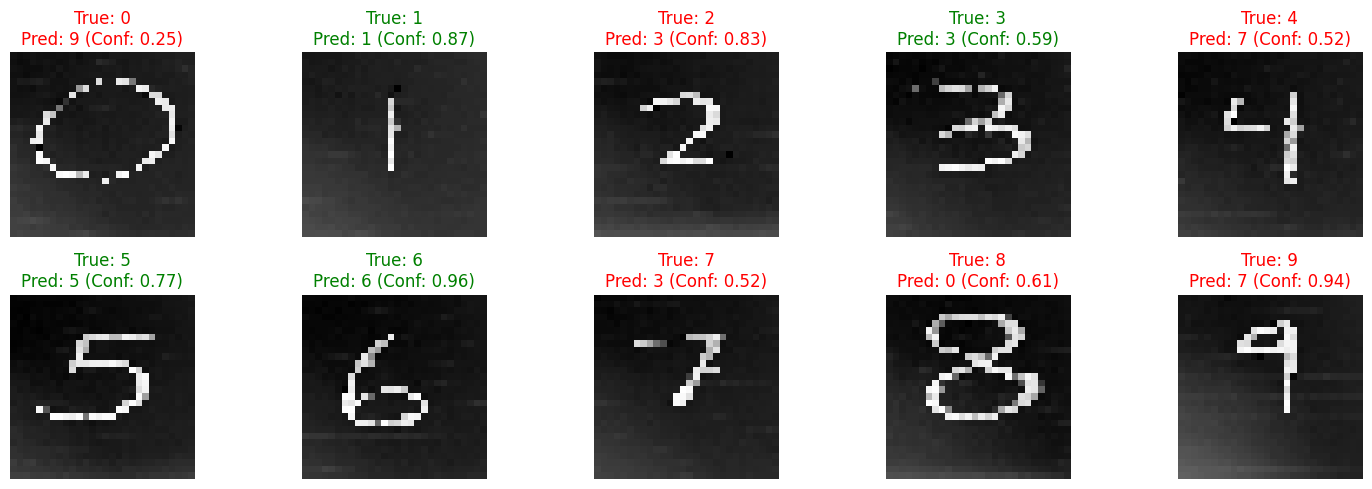

In [17]:
import glob
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


folder_path = './handwritten_digits_thomas/*.jpg'

image_files = glob.glob(folder_path)
image_files.sort()

print(f"Processing {len(image_files)} potential files found at {folder_path}")

# 1. Setup the plot
plt.figure(figsize=(15, 5))
plot_index = 1 # We'll only increment this for valid files

for file_path in image_files:
    try:
        # --- Safely Extract True Label ---
        filename = os.path.basename(file_path) # e.g., '5.jpg'
        digit_str = filename.split('.')[0]      # e.g., '5'
        true_label = int(digit_str)             # e.g., 5

        # We only want digits 0-9
        if true_label < 0 or true_label > 9:
            print(f"Skipping {file_path}: Label {true_label} is out of range 0-9.")
            continue

        # --- Image Processing and Prediction ---
        img = load_img(file_path, color_mode='grayscale', target_size=(28, 28))
        img_array = img_to_array(img)

        # Color inversion and normalization
        img_array = 255.0 - img_array
        img_array = img_array / 255.0

        img_ready = img_array.reshape(1, 28, 28, 1)

        # Predict
        prediction = cnn_model.predict(img_ready, verbose=0)
        predicted_digit = np.argmax(prediction)
        confidence = np.max(prediction)

        # Plotting
        plt.subplot(2, 5, plot_index)
        plt.imshow(img_ready.reshape(28, 28), cmap='gray')

        # Green title if correct, Red if wrong
        color = 'green' if predicted_digit == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {predicted_digit} (Conf: {confidence:.2f})", color=color)
        plt.axis('off')

        plot_index += 1 # Only increment if the file was valid and plotted

    except ValueError:
        # This catches the 'invalid literal for int()' error from files like '.DS_Store'
        print(f"Skipping non-digit file: {file_path}")
        continue
    except Exception as e:
        # Catch other errors, like bad image files
        print(f"Error processing {file_path}: {e}")
        continue

plt.tight_layout()
plt.show()

## Analysis of Hand-Written Digit Prediction using CNN
Using my handwritten digits, the cnn model was able to predict (guess) 4/10 total digits. Out of the four digits guessed correctly, three of them have above 80% confidence, showing us that it wasn't merely by chance that the model correctly guessed those digits. However, the other size incorrectly guessed digits show us that the model could not correctly identify 2, 4, 5, 7, 8, and 9. The following reasons may provide insight as to why this may be the case.
### The "Inversion" Problem
When cropping was performed on each of the images, the uneven lighting in the background caused the blacks (the white paper inverted) to not be equally black like it may have been in the training dataset. The model may interpret this noise as part (or not a part) of the digit. The digits 3 and 7 are a good example of this.
### Centering
MNIST digits are centered by mass. Some of these digits are slightly off-centered, so CNN, being translation invariant but not translation immune, might struggle, especially near the edges of the images or digit itself.
### Stroke Width
Initially, I had used thinner lines to create each digit, but the model could barely find any of the digits. Hence, I needed to increase the boldness of each digit to be more clearly visible by the model. Either way, A sharpie marker like I used may be thicker or thinner than the normalized strokes in the MNIST dataset.
### Writing Style
Some numbers are written differently depending on the region or preference of the writer. For example, I cross my 7s to be clearly different from a 1 or a 2. However, the model may have seen this dash and thus interpreted it as a 3 digit. The number 1 is written in a few different ways, either a straight line (like how I did it), or it could have a base and a flag. If my writing style differs from the training dataset, it will most likely fail.